In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/austinreese/craigslist-carstrucks-data/vehicles.csv


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/kaggle/input/datasets/austinreese/craigslist-carstrucks-data/vehicles.csv")
print(df.shape)
print(df.info())
print(df.describe())
print(df.columns)
print(df.isnull().sum()/len(df)*100)
print(df.duplicated().sum())
print(df.head())

(426880, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  obje

In [3]:
df=df.drop(["id","url","region_url","VIN","size","image_url","county","description","lat","long"],axis=1)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        426880 non-null  object 
 1   price         426880 non-null  int64  
 2   year          425675 non-null  float64
 3   manufacturer  409234 non-null  object 
 4   model         421603 non-null  object 
 5   condition     252776 non-null  object 
 6   cylinders     249202 non-null  object 
 7   fuel          423867 non-null  object 
 8   odometer      422480 non-null  float64
 9   title_status  418638 non-null  object 
 10  transmission  424324 non-null  object 
 11  drive         296313 non-null  object 
 12  type          334022 non-null  object 
 13  paint_color   296677 non-null  object 
 14  state         426880 non-null  object 
 15  posting_date  426812 non-null  object 
dtypes: float64(2), int64(1), object(13)
memory usage: 52.1+ MB


In [5]:
cat_cols=["condition","cylinders","drive","type","paint_color"]

for cols in cat_cols:
    df[cols]=df[cols].fillna("Unknown")

cat_cols_mode=["year","manufacturer","model","fuel","title_status","transmission","state","posting_date"]

for cols in cat_cols_mode:
    df[cols]=df[cols].fillna(df[cols].mode()[0])

int_cols=["odometer"]

for cols in int_cols:
    df[cols]=df[cols].fillna(df[cols].mean())
    

In [6]:
df.isnull().sum()/len(df)*100

region          0.0
price           0.0
year            0.0
manufacturer    0.0
model           0.0
condition       0.0
cylinders       0.0
fuel            0.0
odometer        0.0
title_status    0.0
transmission    0.0
drive           0.0
type            0.0
paint_color     0.0
state           0.0
posting_date    0.0
dtype: float64

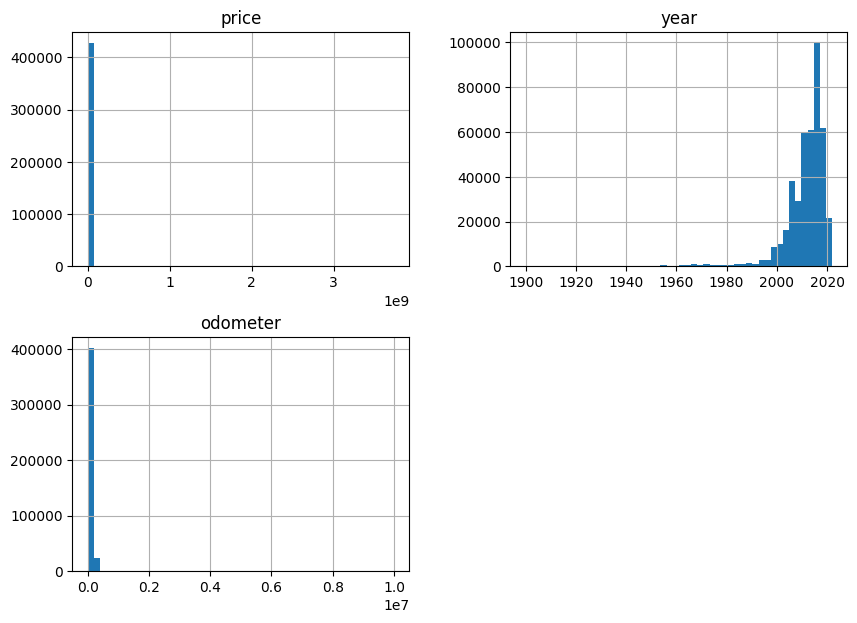

In [7]:
df.hist(figsize=(10,7),bins=50)
plt.title("Int Cols Distribution")
plt.show()

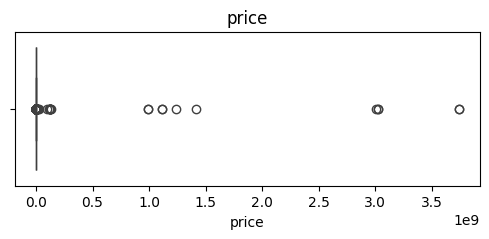

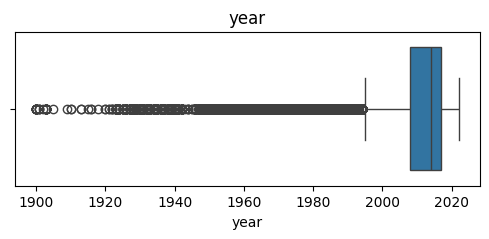

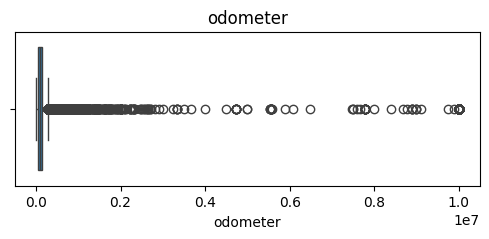

In [8]:
num_cols = df.select_dtypes(include='number').columns
for col in num_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [9]:
import numpy as np

In [10]:
for col in ['price','odometer','year']:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR

    Outliers=df[(df[col]<lower)|(df[col]>upper)]
    print(f"IQR BOUNDS {lower},{upper}")
    print(f"Number of outliers: {len(Outliers)} ({len(Outliers)/len(df)*100:.2f}%)")
    print("Min values:", df[col].nsmallest(5).tolist())
    print("Max values:", df[col].nlargest(5).tolist())

IQR BOUNDS -24978.625,57364.375
Number of outliers: 8177 (1.92%)
Min values: [0, 0, 0, 0, 0]
Max values: [3736928711, 3736928711, 3024942282, 3024942282, 3009548743]
IQR BOUNDS -104175.0,275305.0
Number of outliers: 4481 (1.05%)
Min values: [0.0, 0.0, 0.0, 0.0, 0.0]
Max values: [10000000.0, 10000000.0, 10000000.0, 10000000.0, 10000000.0]
IQR BOUNDS 1994.5,2030.5
Number of outliers: 15896 (3.72%)
Min values: [1900.0, 1900.0, 1900.0, 1900.0, 1900.0]
Max values: [2022.0, 2022.0, 2022.0, 2022.0, 2022.0]


In [11]:
df=df[(df['price']>500) & (df['price']<150000)]
df=df[(df['odometer']>0) & (df['odometer']<250000)]
df=df[(df['year']>1996) & (df['year']<2022)]

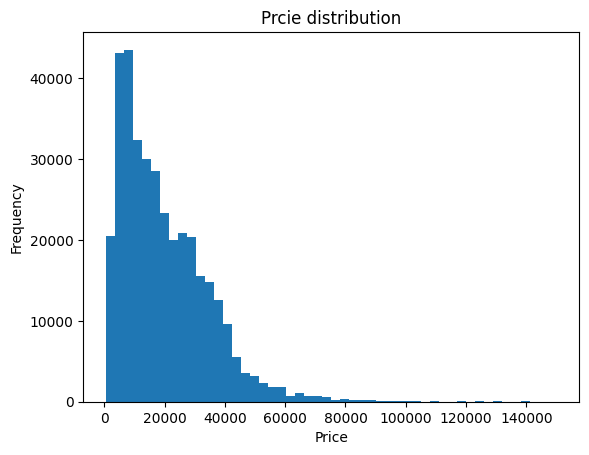

In [12]:
plt.hist(df["price"],bins=50)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Prcie distribution")
plt.show()

In [13]:
df['price'].skew()

np.float64(1.4525966040623146)

In [14]:
import seaborn as sns

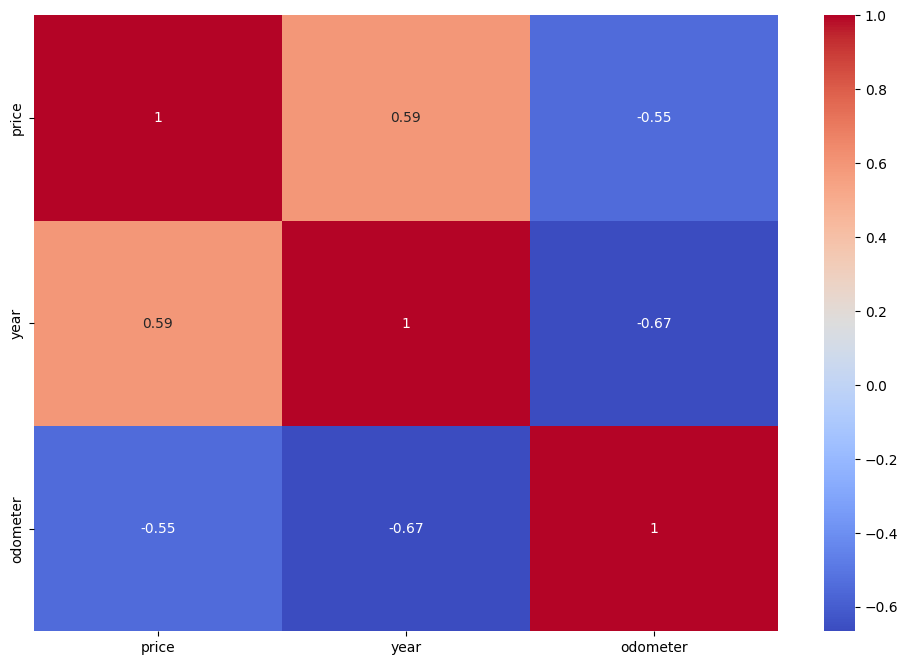

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),annot=True, cmap='coolwarm')
plt.show()

In [16]:
df["posting_date"] = pd.to_datetime(df["posting_date"])

/tmp/ipykernel_58/4111313372.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df["posting_date"] = pd.to_datetime(df["posting_date"])


In [17]:
df.head()

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,posting_date
0,prescott,6000,2017.0,ford,f-150,Unknown,Unknown,gas,98043.331443,clean,automatic,Unknown,Unknown,Unknown,az,2021-04-23 22:13:05-04:00
1,fayetteville,11900,2017.0,ford,f-150,Unknown,Unknown,gas,98043.331443,clean,automatic,Unknown,Unknown,Unknown,ar,2021-04-23 22:13:05-04:00
2,florida keys,21000,2017.0,ford,f-150,Unknown,Unknown,gas,98043.331443,clean,automatic,Unknown,Unknown,Unknown,fl,2021-04-23 22:13:05-04:00
3,worcester / central MA,1500,2017.0,ford,f-150,Unknown,Unknown,gas,98043.331443,clean,automatic,Unknown,Unknown,Unknown,ma,2021-04-23 22:13:05-04:00
4,greensboro,4900,2017.0,ford,f-150,Unknown,Unknown,gas,98043.331443,clean,automatic,Unknown,Unknown,Unknown,nc,2021-04-23 22:13:05-04:00


In [18]:
cat_cols=df.select_dtypes(include=['object']).columns

for cols in cat_cols:
    print(df[cols].value_counts())

region
columbus                  3127
jacksonville              2903
omaha / council bluffs    2817
grand rapids              2807
central NJ                2765
                          ... 
meridian                    17
southwest MS                12
kansas city                  8
west virginia (old)          7
fort smith, AR               7
Name: count, Length: 404, dtype: int64
manufacturer
ford               70448
chevrolet          44334
toyota             29258
honda              18717
nissan             16465
jeep               15775
ram                15483
gmc                14273
bmw                13158
dodge              11022
mercedes-benz       9485
hyundai             9024
subaru              8631
volkswagen          7960
lexus               7442
kia                 7260
audi                6981
cadillac            5964
acura               5464
chrysler            5336
buick               4772
mazda               4759
infiniti            4379
lincoln             3791


In [19]:
from sklearn.model_selection import train_test_split
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [20]:
x=df.drop(['price'],axis=1)
y=df['price']

In [21]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [22]:
cat_cols_te=['region','model','posting_date']
cat_cols_or=['manufacturer','state']
cat_cols_oe=['condition','cylinders','paint_color','type','fuel','drive','transmission','title_status']

In [23]:
from sklearn.compose import ColumnTransformer
from category_encoders import TargetEncoder
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder

processor=ColumnTransformer(
    transformers=[
    ("TargetEncoding",TargetEncoder(),cat_cols_te),
    ("Ordinal",OrdinalEncoder(),cat_cols_or),
    ("OneHot",OneHotEncoder(),cat_cols_oe)
    ],
    remainder="passthrough"
)
x_train=processor.fit_transform(x_train,y_train)
x_test=processor.transform(x_test)

In [24]:
import joblib

joblib.dump(processor, "processor.pkl")

['processor.pkl']

In [27]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators",
            100,
            500
        ),
        "max_depth": trial.suggest_int(
            "max_depth",
            5,
            40
        ),
        "min_samples_split": trial.suggest_int(
            "min_samples_split",
            2,
            20
        ),
        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf",
            1,
            10
        ),
        "max_features": trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2"]
        ),
        "random_state":42,
        "n_jobs":-1
    }
    model = RandomForestRegressor(**params)
    score = cross_val_score(
        model,
        x_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    return score.mean()

study=optuna.create_study(direction="maximize")
study.optimize(objective,n_trials=5)
print(study.best_params)

[I 2026-07-10 11:47:10,336] A new study created in memory with name: no-name-5dcbb21e-8df8-46c8-8b8b-50abef618b06
[I 2026-07-10 12:12:00,887] Trial 0 finished with value: -3814.5877813307743 and parameters: {'n_estimators': 260, 'max_depth': 39, 'min_samples_split': 3, 'min_samples_leaf': 8, 'max_features': 'sqrt'}. Best is trial 0 with value: -3814.5877813307743.
[I 2026-07-10 12:21:29,315] Trial 1 finished with value: -3913.571500173943 and parameters: {'n_estimators': 107, 'max_depth': 34, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 0 with value: -3814.5877813307743.
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[I 2026-07-10 13:00:19,861] Trial 2 finished with value: -3612.837610350791 and parameters: {'n_estimators': 324, 'max_depth': 35, 

{'n_estimators': 324, 'max_depth': 35, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': 'sqrt'}


In [29]:
pip install mlflow

Note: you may need to restart the kernel to use updated packages.


In [30]:
import mlflow
import mlflow.sklearn

with mlflow.start_run(run_name="RandomForest_Optuna"):
    best_model = RandomForestRegressor(
        **study.best_params,
        random_state=42,
        n_jobs=-1
    )
    best_model.fit(x_train, y_train)
    pred = best_model.predict(x_test)
    mse=mean_squared_error(y_test,pred)
    mae=mean_absolute_error(y_test,pred)
    r2=r2_score(y_test,pred)
    
    joblib.dump(best_model, "best_random_forest.pkl")

    mlflow.log_params(study.best_params)
    mlflow.log_metric("mse",mse)
    mlflow.log_metric("mae",mae)
    mlflow.log_metric("r2",r2)

    mlflow.sklearn.log_model(
        sk_model=best_model,
        artifact_path="random_forest_model"
    )

print("Best Parameters:", study.best_params)
print("RMSE:",mse)
print("MAE:",mae)
print("R2 Score:",r2)

2026/07/10 13:54:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Best Parameters: {'n_estimators': 324, 'max_depth': 35, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': 'sqrt'}
RMSE: 74048956.8729056
MAE: 5203.325594836248
R2 Score: 0.659765544875476
